# Prévision de la Température et de l'Irradiation Solaire — Benguerir (2026–2055)

## LSTM Bidirectionnel + Post-processing physique

**Données** : NASA POWER — T2M (°C) + ALLSKY (W/m²) — 2001 à 2025  
**Modèle** : LSTM Bidirectionnel + Lag Features  
**Entraînement** : batch_size=16 | **Prédiction** : batch_size=32  
**Prévision** : 30 ans (2026–2055) — autorégressive, un seul entraînement

**Post-processing physique :**
- **ALLSKY** : forcé à 0.00 W/m² la nuit (heures 0–5, 21–23)
- **T2M** : ré-scaling statistique par mois×heure pour restaurer la variabilité réelle (min/max extrêmes)


## 1. Imports et Configuration


In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import gc
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
tf.get_logger().setLevel("ERROR")
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber

np.random.seed(42)
tf.random.set_seed(42)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print(f"✓ GPU détecté : {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("⚠ Aucun GPU détecté — exécution CPU")

print(f"TensorFlow : {tf.__version__}")


✓ GPU détecté : /physical_device:GPU:0
TensorFlow : 2.10.0


## 2. Chargement des Données


In [4]:
df = pd.read_csv("data_horaire.csv")
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.set_index("datetime")

print(f"Données : {len(df)} heures | {df.index[0]} → {df.index[-1]}")
print(f"T2M   — Min={df['T2M'].min():.1f}°C | Max={df['T2M'].max():.1f}°C | Moy={df['T2M'].mean():.1f}°C | Std={df['T2M'].std():.1f}°C")
print(f"ALLSKY — Min={df['ALLSKY'].min():.1f} | Max={df['ALLSKY'].max():.1f} | Moy={df['ALLSKY'].mean():.1f} W/m²")
print(f"\nNaN : T2M={df['T2M'].isna().sum()}, ALLSKY={df['ALLSKY'].isna().sum()}")

# Traitement NaN ALLSKY
df["ALLSKY"] = df["ALLSKY"].interpolate(method="linear", limit=48)
df["_month"] = df.index.month
df["_hour"] = df.index.hour
monthly_hourly_mean = df.groupby(["_month", "_hour"])["ALLSKY"].transform("mean")
df["ALLSKY"] = df["ALLSKY"].fillna(monthly_hourly_mean)
df = df.drop(columns=["_month", "_hour"])
print(f"NaN après remplissage : T2M={df['T2M'].isna().sum()}, ALLSKY={df['ALLSKY'].isna().sum()}")


Données : 219144 heures | 2001-01-01 00:00:00 → 2025-12-31 23:00:00
T2M   — Min=-3.4°C | Max=47.5°C | Moy=19.9°C | Std=8.5°C
ALLSKY — Min=0.0 | Max=1065.6 | Moy=234.0 W/m²

NaN : T2M=0, ALLSKY=762
NaN après remplissage : T2M=0, ALLSKY=0


## 3. Statistiques climatiques de référence (pour post-processing)

On calcule les profils mensuels × horaires (moyenne, std, min, max) des données originales.
Ces statistiques serviront à **corriger les prévisions** pour restaurer la variabilité réelle.


In [5]:
# ── Statistiques climatiques de référence (mois × heure) ─────────
# Ces stats seront utilisées pour le post-processing des prévisions
df["_month"] = df.index.month
df["_hour"]  = df.index.hour

# T2M : profil moyen + std + min + max par (mois, heure)
t2m_stats = df.groupby(["_month", "_hour"])["T2M"].agg(["mean", "std", "min", "max"]).reset_index()
t2m_stats.columns = ["month", "hour", "t_mean", "t_std", "t_min", "t_max"]

# ALLSKY : profil moyen par (mois, heure) + heures nocturnes
allsky_stats = df.groupby(["_month", "_hour"])["ALLSKY"].agg(["mean", "std", "min", "max"]).reset_index()
allsky_stats.columns = ["month", "hour", "s_mean", "s_std", "s_min", "s_max"]

df = df.drop(columns=["_month", "_hour"])

print("Statistiques T2M de référence (exemples mois 7 = Juillet) :")
print(t2m_stats[t2m_stats["month"]==7][["hour","t_mean","t_std","t_min","t_max"]].to_string(index=False))
print(f"\n  → T2M max absolu dans les données : {df['T2M'].max():.1f}°C")
print(f"  → T2M min absolu dans les données : {df['T2M'].min():.1f}°C")
print(f"\nStatistiques ALLSKY (exemples mois 7 = Juillet, heures nocturnes) :")
print(allsky_stats[(allsky_stats["month"]==7) & (allsky_stats["hour"].isin([0,1,2,3,22,23]))][["hour","s_mean","s_max"]].to_string(index=False))


Statistiques T2M de référence (exemples mois 7 = Juillet) :
 hour    t_mean    t_std  t_min  t_max
    0 21.860516 3.417199  14.98  33.69
    1 21.273652 3.479392  14.42  32.60
    2 20.734697 3.524390  13.79  31.58
    3 20.264761 3.544846  13.10  31.42
    4 19.942181 3.538732  12.59  31.28
    5 20.988942 3.683062  13.72  32.64
    6 23.418452 4.000811  16.51  36.69
    7 26.541187 4.391974  19.55  40.40
    8 29.779665 4.679841  21.76  43.49
    9 32.658077 4.682028  24.20  45.24
   10 35.022581 4.546253  26.13  46.21
   11 36.806503 4.365770  27.67  46.94
   12 37.923277 4.162413  28.78  47.37
   13 38.319226 3.976953  29.35  47.50
   14 38.022774 3.796781  29.57  47.19
   15 37.004245 3.636462  29.26  46.28
   16 35.266348 3.513192  27.57  44.77
   17 32.794981 3.348347  25.25  42.27
   18 29.540090 3.114212  22.36  38.95
   19 27.134297 3.111682  19.96  37.63
   20 25.433484 3.156709  18.37  36.41
   21 24.217819 3.222233  17.52  35.64
   22 23.324516 3.281572  16.80  35.27
   2

## 4. Feature Engineering + Fonctions


In [6]:
def create_features(dataframe):
    d = dataframe.copy()
    idx = d.index
    d["hour"]         = idx.hour
    d["day_of_week"]  = idx.dayofweek
    d["month"]        = idx.month
    d["day_of_year"]  = idx.dayofyear
    d["week_of_year"] = idx.isocalendar().week.astype(int).values
    d["quarter"]      = idx.quarter
    d["hour_sin"] = np.sin(2 * np.pi * idx.hour / 24)
    d["hour_cos"] = np.cos(2 * np.pi * idx.hour / 24)
    d["dow_sin"]  = np.sin(2 * np.pi * idx.dayofweek / 7)
    d["dow_cos"]  = np.cos(2 * np.pi * idx.dayofweek / 7)
    d["moy_sin"]  = np.sin(2 * np.pi * idx.month / 12)
    d["moy_cos"]  = np.cos(2 * np.pi * idx.month / 12)
    d["doy_sin"]  = np.sin(2 * np.pi * idx.dayofyear / 365.25)
    d["doy_cos"]  = np.cos(2 * np.pi * idx.dayofyear / 365.25)
    d["is_daytime"]   = ((idx.hour >= 6) & (idx.hour <= 19)).astype(int)
    d["solar_peak"]   = ((idx.hour >= 10) & (idx.hour <= 15)).astype(int)
    d["night"]        = ((idx.hour >= 21) | (idx.hour <= 4)).astype(int)
    d["is_summer"] = ((idx.month >= 6) & (idx.month <= 8)).astype(int)
    d["is_winter"] = ((idx.month == 12) | (idx.month <= 2)).astype(int)
    d["hour_x_month"]  = d["hour"] * d["month"]
    d["hour_x_summer"] = d["hour"] * d["is_summer"]
    return d

def create_features_with_lags(dataframe, target_col):
    d = create_features(dataframe)
    for lag in [1, 2, 3, 6, 12, 24, 48, 72]:
        d[f"lag_{lag}h"] = d[target_col].shift(lag)
    d["rolling_24h_mean"] = d[target_col].rolling(24, min_periods=1).mean()
    d["rolling_72h_mean"] = d[target_col].rolling(72, min_periods=1).mean()
    d["rolling_24h_std"]  = d[target_col].rolling(24, min_periods=1).std().fillna(0)
    d = d.dropna()
    return d

def calc_metrics(y_true, y_pred):
    return {"R²": r2_score(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "MAE": mean_absolute_error(y_true, y_pred)}

def make_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

def safe_predict(model, X, batch_size=32):
    preds = []
    for i in range(0, len(X), batch_size):
        preds.append(model.predict(X[i:i+batch_size], verbose=0))
    return np.vstack(preds)

def build_bilstm(lookback, n_features):
    model = Sequential([
        Bidirectional(LSTM(128, return_sequences=True), input_shape=(lookback, n_features)),
        Dropout(0.3),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.3),
        LSTM(32),
        Dropout(0.2),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
                  loss=Huber(delta=1.0), metrics=["mae"])
    return model

print("✓ Fonctions définies")


✓ Fonctions définies


---
# ════════════════════════════════════════════════════════════════
# PARTIE A — TEMPÉRATURE (T2M)
# ════════════════════════════════════════════════════════════════


## 5. Préparation + Entraînement LSTM — T2M


In [7]:
LOOKBACK = 72

df_feat_lag_t = create_features_with_lags(df[["T2M"]], "T2M")
feature_cols_lag_t = [c for c in df_feat_lag_t.columns if c != "T2M"]
print(f"Features T2M : {len(feature_cols_lag_t)}")

X_all_lag_t = df_feat_lag_t[feature_cols_lag_t].values
y_all_lag_t = df_feat_lag_t["T2M"].values

scaler_X_t = MinMaxScaler()
scaler_y_t = MinMaxScaler()
X_sc_t = scaler_X_t.fit_transform(X_all_lag_t)
y_sc_t = scaler_y_t.fit_transform(y_all_lag_t.reshape(-1, 1)).flatten()

X_seq_t, y_seq_t = make_sequences(X_sc_t, y_sc_t, LOOKBACK)
sp_t = int(len(X_seq_t) * 0.8)
X_tr_lstm_t, X_te_lstm_t = X_seq_t[:sp_t], X_seq_t[sp_t:]
y_tr_lstm_t, y_te_lstm_t = y_seq_t[:sp_t], y_seq_t[sp_t:]
print(f"Train : {X_tr_lstm_t.shape}  |  Test : {X_te_lstm_t.shape}")


Features T2M : 32
Train : (175200, 72, 32)  |  Test : (43800, 72, 32)


In [8]:
model_lstm_t = build_bilstm(LOOKBACK, len(feature_cols_lag_t))
model_lstm_t.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional (Bidirectiona  (None, 72, 256)          164864    
 l)                                                              
                                                                 
 dropout (Dropout)           (None, 72, 256)           0         
                                                                 
 bidirectional_1 (Bidirectio  (None, 72, 128)          164352    
 nal)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 72, 128)           0         
                                                                 
 lstm_2 (LSTM)               (None, 32)                20608     
                                                                 
 dropout_2 (Dropout)         (None, 32)                0

In [9]:
print("Entraînement LSTM T2M (batch_size=16)...")
history_t = model_lstm_t.fit(
    X_tr_lstm_t, y_tr_lstm_t,
    validation_data=(X_te_lstm_t, y_te_lstm_t),
    epochs=50, batch_size=16,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-9, verbose=1)
    ],
    verbose=2
)


Entraînement LSTM T2M (batch_size=16)...
Epoch 1/50
10950/10950 - 462s - loss: 6.7489e-04 - mae: 0.0260 - val_loss: 7.1857e-04 - val_mae: 0.0290 - lr: 0.0010 - 462s/epoch - 42ms/step
Epoch 2/50
10950/10950 - 449s - loss: 2.4842e-04 - mae: 0.0171 - val_loss: 9.6701e-04 - val_mae: 0.0320 - lr: 0.0010 - 449s/epoch - 41ms/step
Epoch 3/50
10950/10950 - 441s - loss: 1.8378e-04 - mae: 0.0146 - val_loss: 8.9943e-04 - val_mae: 0.0316 - lr: 0.0010 - 441s/epoch - 40ms/step
Epoch 4/50

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
10950/10950 - 434s - loss: 1.5747e-04 - mae: 0.0135 - val_loss: 8.9550e-04 - val_mae: 0.0328 - lr: 0.0010 - 434s/epoch - 40ms/step
Epoch 5/50
10950/10950 - 433s - loss: 1.1838e-04 - mae: 0.0115 - val_loss: 8.8426e-04 - val_mae: 0.0317 - lr: 5.0000e-04 - 433s/epoch - 40ms/step
Epoch 6/50
10950/10950 - 410s - loss: 1.1274e-04 - mae: 0.0112 - val_loss: 0.0010 - val_mae: 0.0346 - lr: 5.0000e-04 - 410s/epoch - 37ms/step
Epoch 7/50

Epoch 7: Reduc

## 6. Métriques & Visualisation — T2M


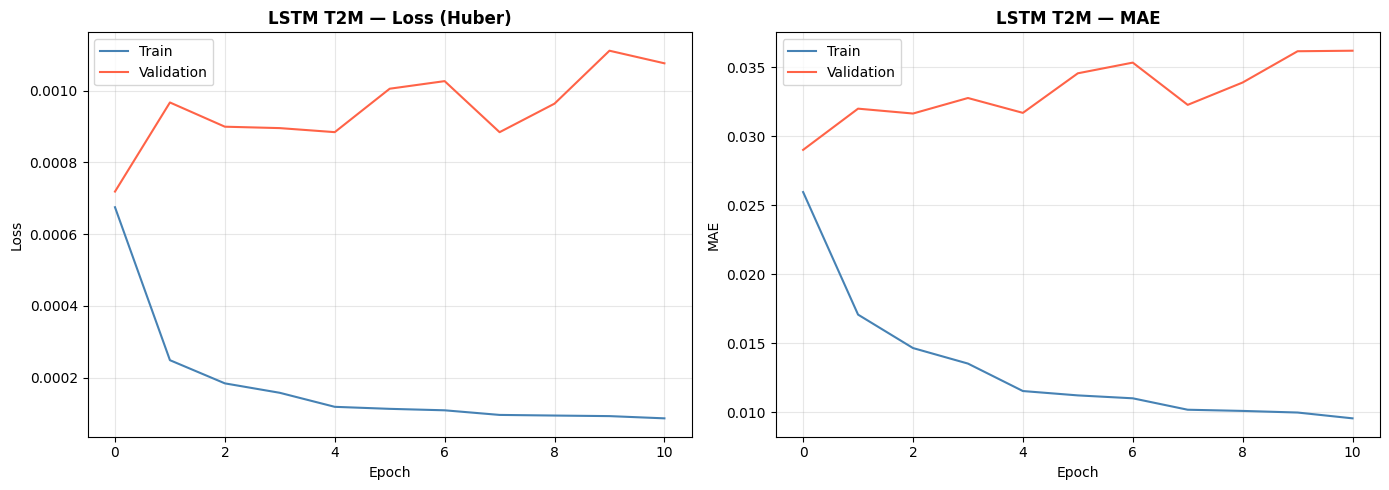

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_t.history["loss"], label="Train", color="steelblue")
axes[0].plot(history_t.history["val_loss"], label="Validation", color="tomato")
axes[0].set_title("LSTM T2M — Loss (Huber)", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history_t.history["mae"], label="Train", color="steelblue")
axes[1].plot(history_t.history["val_mae"], label="Validation", color="tomato")
axes[1].set_title("LSTM T2M — MAE", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [ ]:
gc.collect()
ytr_lstm_t = scaler_y_t.inverse_transform(safe_predict(model_lstm_t, X_tr_lstm_t, batch_size=16).reshape(-1, 1)).flatten()
yte_lstm_t = scaler_y_t.inverse_transform(safe_predict(model_lstm_t, X_te_lstm_t, batch_size=16).reshape(-1, 1)).flatten()
ytr_real_t = scaler_y_t.inverse_transform(y_tr_lstm_t.reshape(-1, 1)).flatten()
yte_real_t = scaler_y_t.inverse_transform(y_te_lstm_t.reshape(-1, 1)).flatten()

lstm_train_mt = calc_metrics(ytr_real_t, ytr_lstm_t)
lstm_test_mt  = calc_metrics(yte_real_t, yte_lstm_t)

print(f"╔{'═'*62}╗")
print(f"║  MÉTRIQUES LSTM T2M — TRAIN + TEST{' '*26}║")
print(f"╚{'═'*62}╝")
print(f"  TRAIN →  R²={lstm_train_mt['R²']:.4f}  |  RMSE={lstm_train_mt['RMSE']:.4f} °C  |  MAE={lstm_train_mt['MAE']:.4f} °C")
print(f"  TEST  →  R²={lstm_test_mt['R²']:.4f}  |  RMSE={lstm_test_mt['RMSE']:.4f} °C  |  MAE={lstm_test_mt['MAE']:.4f} °C")


╔══════════════════════════════════════════════════════════════╗
║  MÉTRIQUES LSTM T2M — TRAIN + TEST                          ║
╚══════════════════════════════════════════════════════════════╝
  TRAIN →  R²=0.9554  |  RMSE=1.8103 °C  |  MAE=1.3804 °C
  TEST  →  R²=0.9471  |  RMSE=1.9281 °C  |  MAE=1.4755 °C


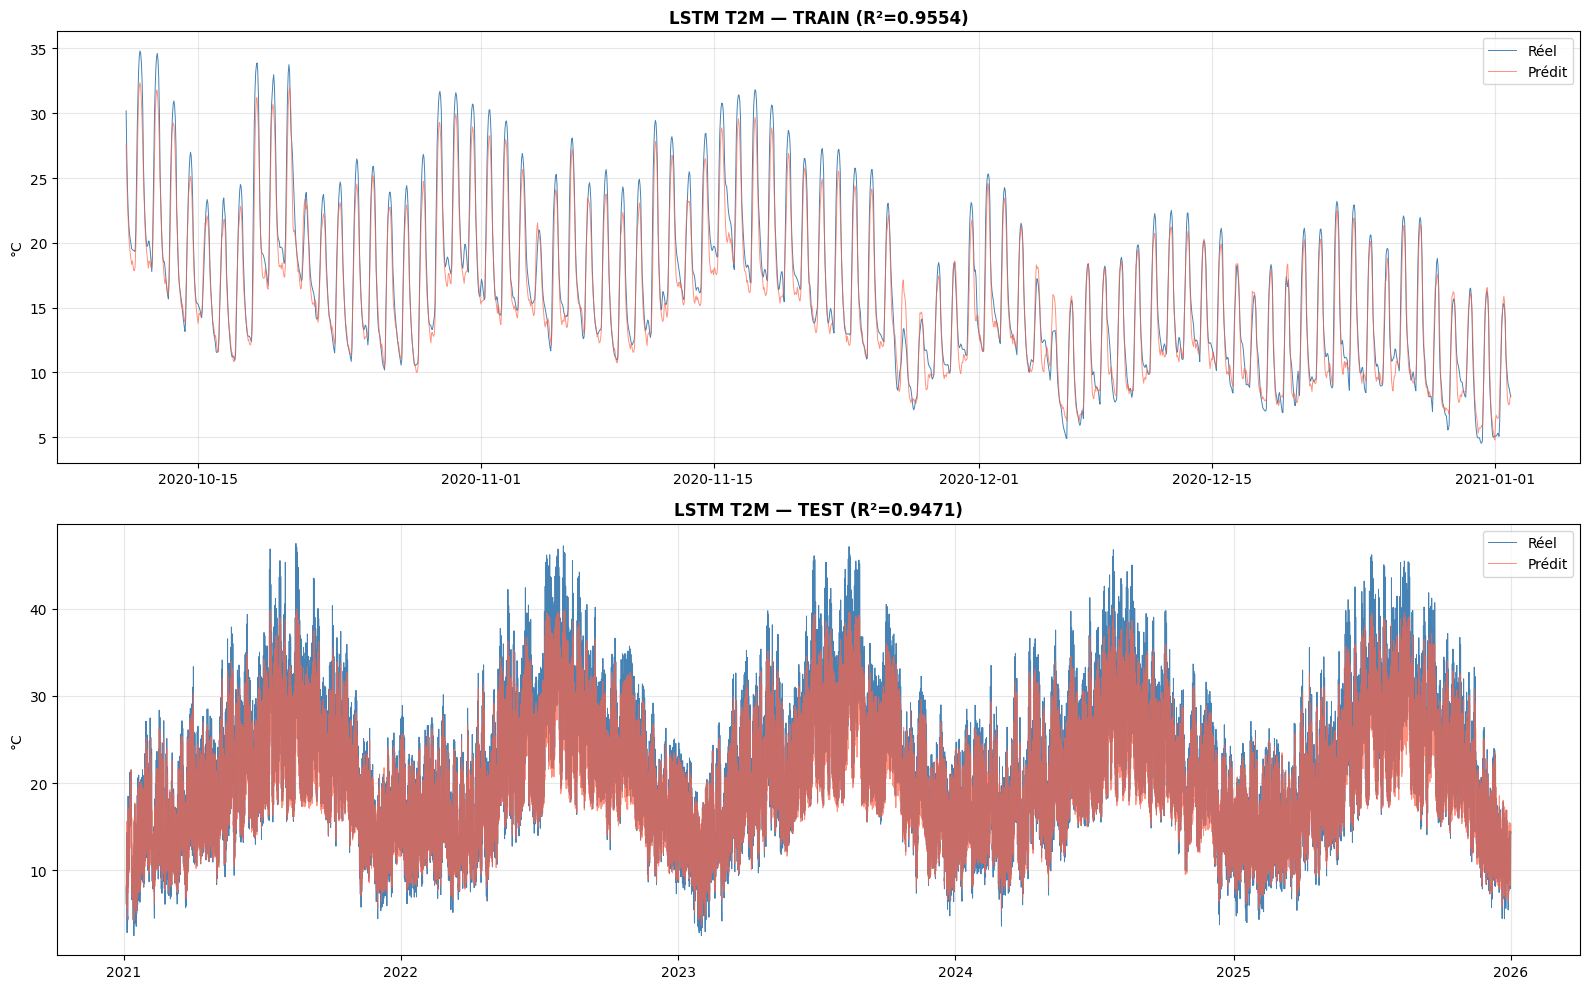

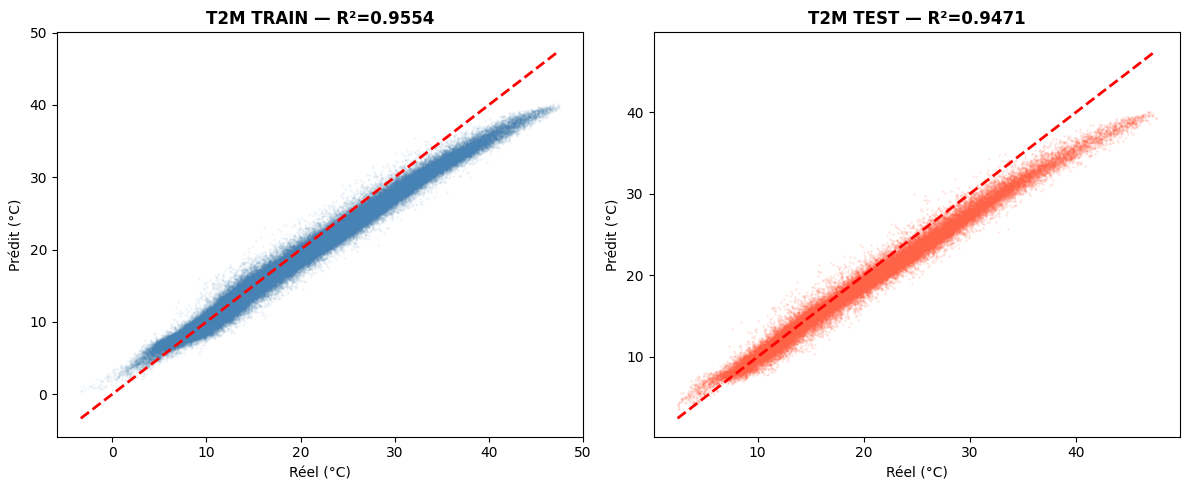

In [12]:
split_idx_lag_t = int(len(df_feat_lag_t) * 0.8)
train_idx_lstm_t = df_feat_lag_t.index[LOOKBACK:LOOKBACK + len(ytr_real_t)]
test_idx_lstm_t  = df_feat_lag_t.index[split_idx_lag_t + LOOKBACK:][:len(yte_real_t)]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
axes[0].plot(train_idx_lstm_t[-2000:], ytr_real_t[-2000:], lw=0.7, color="steelblue", label="Réel")
axes[0].plot(train_idx_lstm_t[-2000:], ytr_lstm_t[-2000:], lw=0.7, color="tomato", alpha=0.7, label="Prédit")
axes[0].set_title(f"LSTM T2M — TRAIN (R²={lstm_train_mt['R²']:.4f})", fontweight="bold")
axes[0].legend(); axes[0].set_ylabel("°C"); axes[0].grid(True, alpha=0.3)

n_te = min(len(test_idx_lstm_t), len(yte_real_t))
axes[1].plot(test_idx_lstm_t[:n_te], yte_real_t[:n_te], lw=0.7, color="steelblue", label="Réel")
axes[1].plot(test_idx_lstm_t[:n_te], yte_lstm_t[:n_te], lw=0.7, color="tomato", alpha=0.7, label="Prédit")
axes[1].set_title(f"LSTM T2M — TEST (R²={lstm_test_mt['R²']:.4f})", fontweight="bold")
axes[1].legend(); axes[1].set_ylabel("°C"); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(ytr_real_t, ytr_lstm_t, s=1, alpha=0.05, color="steelblue")
axes[0].plot([ytr_real_t.min(), ytr_real_t.max()], [ytr_real_t.min(), ytr_real_t.max()], "r--", lw=2)
axes[0].set_xlabel("Réel (°C)"); axes[0].set_ylabel("Prédit (°C)")
axes[0].set_title(f"T2M TRAIN — R²={lstm_train_mt['R²']:.4f}", fontweight="bold")
axes[1].scatter(yte_real_t, yte_lstm_t, s=1, alpha=0.1, color="tomato")
axes[1].plot([yte_real_t.min(), yte_real_t.max()], [yte_real_t.min(), yte_real_t.max()], "r--", lw=2)
axes[1].set_xlabel("Réel (°C)"); axes[1].set_ylabel("Prédit (°C)")
axes[1].set_title(f"T2M TEST — R²={lstm_test_mt['R²']:.4f}", fontweight="bold")
plt.tight_layout(); plt.show()


---
# ════════════════════════════════════════════════════════════════
# PARTIE B — IRRADIATION (ALLSKY)
# ════════════════════════════════════════════════════════════════


## 7. Préparation + Entraînement LSTM — ALLSKY


In [13]:
df_feat_lag_s = create_features_with_lags(df[["ALLSKY"]], "ALLSKY")
feature_cols_lag_s = [c for c in df_feat_lag_s.columns if c != "ALLSKY"]
print(f"Features ALLSKY : {len(feature_cols_lag_s)}")

X_all_lag_s = df_feat_lag_s[feature_cols_lag_s].values
y_all_lag_s = df_feat_lag_s["ALLSKY"].values

scaler_X_s = MinMaxScaler()
scaler_y_s = MinMaxScaler()
X_sc_s = scaler_X_s.fit_transform(X_all_lag_s)
y_sc_s = scaler_y_s.fit_transform(y_all_lag_s.reshape(-1, 1)).flatten()

X_seq_s, y_seq_s = make_sequences(X_sc_s, y_sc_s, LOOKBACK)
sp_s = int(len(X_seq_s) * 0.8)
X_tr_lstm_s, X_te_lstm_s = X_seq_s[:sp_s], X_seq_s[sp_s:]
y_tr_lstm_s, y_te_lstm_s = y_seq_s[:sp_s], y_seq_s[sp_s:]
print(f"Train : {X_tr_lstm_s.shape}  |  Test : {X_te_lstm_s.shape}")


Features ALLSKY : 32
Train : (175200, 72, 32)  |  Test : (43800, 72, 32)


In [14]:
gc.collect()
model_lstm_s = build_bilstm(LOOKBACK, len(feature_cols_lag_s))

print("Entraînement LSTM ALLSKY (batch_size=16)...")
history_s = model_lstm_s.fit(
    X_tr_lstm_s, y_tr_lstm_s,
    validation_data=(X_te_lstm_s, y_te_lstm_s),
    epochs=50, batch_size=16,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-9, verbose=1)
    ],
    verbose=2
)


Entraînement LSTM ALLSKY (batch_size=16)...
Epoch 1/50
10950/10950 - 494s - loss: 0.0012 - mae: 0.0276 - val_loss: 0.0011 - val_mae: 0.0257 - lr: 0.0010 - 494s/epoch - 45ms/step
Epoch 2/50
10950/10950 - 485s - loss: 6.6352e-04 - mae: 0.0198 - val_loss: 9.3672e-04 - val_mae: 0.0253 - lr: 0.0010 - 485s/epoch - 44ms/step
Epoch 3/50
10950/10950 - 469s - loss: 5.6957e-04 - mae: 0.0176 - val_loss: 8.2072e-04 - val_mae: 0.0217 - lr: 0.0010 - 469s/epoch - 43ms/step
Epoch 4/50
10950/10950 - 467s - loss: 5.3421e-04 - mae: 0.0168 - val_loss: 9.8246e-04 - val_mae: 0.0238 - lr: 0.0010 - 467s/epoch - 43ms/step
Epoch 5/50
10950/10950 - 462s - loss: 4.9950e-04 - mae: 0.0160 - val_loss: 6.9399e-04 - val_mae: 0.0204 - lr: 0.0010 - 462s/epoch - 42ms/step
Epoch 6/50
10950/10950 - 472s - loss: 4.8667e-04 - mae: 0.0158 - val_loss: 7.6469e-04 - val_mae: 0.0216 - lr: 0.0010 - 472s/epoch - 43ms/step
Epoch 7/50
10950/10950 - 457s - loss: 4.7076e-04 - mae: 0.0153 - val_loss: 6.6326e-04 - val_mae: 0.0196 - lr: 0.

## 8. Métriques & Visualisation — ALLSKY


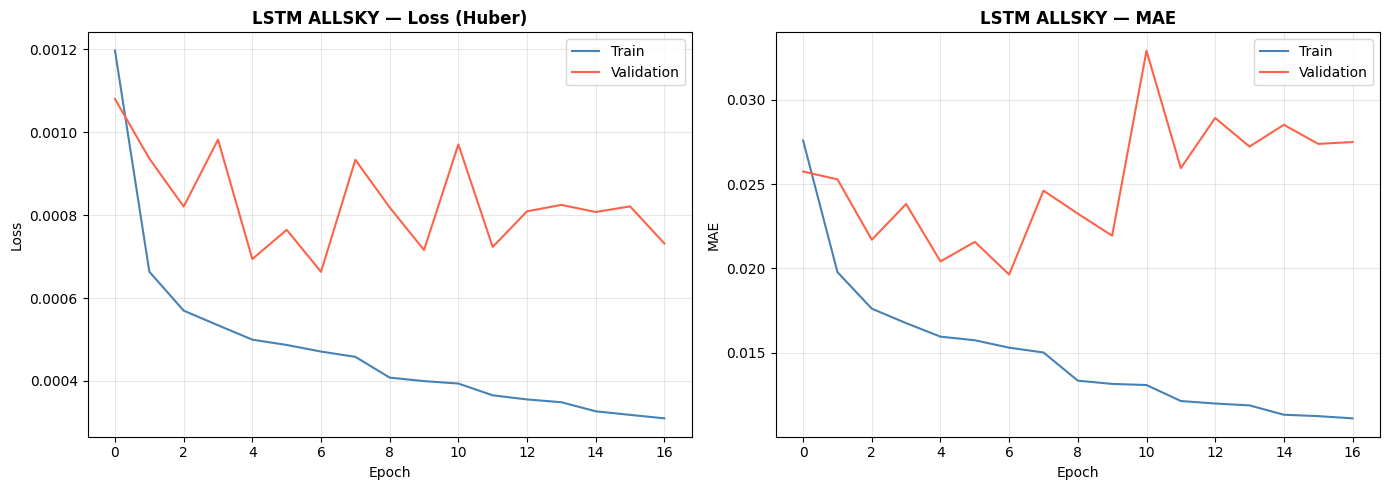

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_s.history["loss"], label="Train", color="steelblue")
axes[0].plot(history_s.history["val_loss"], label="Validation", color="tomato")
axes[0].set_title("LSTM ALLSKY — Loss (Huber)", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history_s.history["mae"], label="Train", color="steelblue")
axes[1].plot(history_s.history["val_mae"], label="Validation", color="tomato")
axes[1].set_title("LSTM ALLSKY — MAE", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [16]:
gc.collect()
ytr_lstm_s = scaler_y_s.inverse_transform(safe_predict(model_lstm_s, X_tr_lstm_s, batch_size=16).reshape(-1, 1)).flatten()
yte_lstm_s = scaler_y_s.inverse_transform(safe_predict(model_lstm_s, X_te_lstm_s, batch_size=16).reshape(-1, 1)).flatten()
ytr_real_s = scaler_y_s.inverse_transform(y_tr_lstm_s.reshape(-1, 1)).flatten()
yte_real_s = scaler_y_s.inverse_transform(y_te_lstm_s.reshape(-1, 1)).flatten()
ytr_lstm_s = np.maximum(ytr_lstm_s, 0)
yte_lstm_s = np.maximum(yte_lstm_s, 0)

lstm_train_ms = calc_metrics(ytr_real_s, ytr_lstm_s)
lstm_test_ms  = calc_metrics(yte_real_s, yte_lstm_s)

print(f"╔{'═'*62}╗")
print(f"║  MÉTRIQUES LSTM ALLSKY — TRAIN + TEST{' '*23}║")
print(f"╚{'═'*62}╝")
print(f"  TRAIN →  R²={lstm_train_ms['R²']:.4f}  |  RMSE={lstm_train_ms['RMSE']:.2f} W/m²  |  MAE={lstm_train_ms['MAE']:.2f} W/m²")
print(f"  TEST  →  R²={lstm_test_ms['R²']:.4f}  |  RMSE={lstm_test_ms['RMSE']:.2f} W/m²  |  MAE={lstm_test_ms['MAE']:.2f} W/m²")


: 

In [ ]:
split_idx_lag_s = int(len(df_feat_lag_s) * 0.8)
train_idx_lstm_s = df_feat_lag_s.index[LOOKBACK:LOOKBACK + len(ytr_real_s)]
test_idx_lstm_s  = df_feat_lag_s.index[split_idx_lag_s + LOOKBACK:][:len(yte_real_s)]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
axes[0].plot(train_idx_lstm_s[-2000:], ytr_real_s[-2000:], lw=0.7, color="steelblue", label="Réel")
axes[0].plot(train_idx_lstm_s[-2000:], ytr_lstm_s[-2000:], lw=0.7, color="tomato", alpha=0.7, label="Prédit")
axes[0].set_title(f"LSTM ALLSKY — TRAIN (R²={lstm_train_ms['R²']:.4f})", fontweight="bold")
axes[0].legend(); axes[0].set_ylabel("W/m²"); axes[0].grid(True, alpha=0.3)
n_te_s = min(len(test_idx_lstm_s), len(yte_real_s))
axes[1].plot(test_idx_lstm_s[:n_te_s], yte_real_s[:n_te_s], lw=0.7, color="steelblue", label="Réel")
axes[1].plot(test_idx_lstm_s[:n_te_s], yte_lstm_s[:n_te_s], lw=0.7, color="tomato", alpha=0.7, label="Prédit")
axes[1].set_title(f"LSTM ALLSKY — TEST (R²={lstm_test_ms['R²']:.4f})", fontweight="bold")
axes[1].legend(); axes[1].set_ylabel("W/m²"); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(ytr_real_s, ytr_lstm_s, s=1, alpha=0.05, color="steelblue")
axes[0].plot([0, ytr_real_s.max()], [0, ytr_real_s.max()], "r--", lw=2)
axes[0].set_xlabel("Réel (W/m²)"); axes[0].set_ylabel("Prédit (W/m²)")
axes[0].set_title(f"ALLSKY TRAIN — R²={lstm_train_ms['R²']:.4f}", fontweight="bold")
axes[1].scatter(yte_real_s, yte_lstm_s, s=1, alpha=0.1, color="tomato")
axes[1].plot([0, yte_real_s.max()], [0, yte_real_s.max()], "r--", lw=2)
axes[1].set_xlabel("Réel (W/m²)"); axes[1].set_ylabel("Prédit (W/m²)")
axes[1].set_title(f"ALLSKY TEST — R²={lstm_test_ms['R²']:.4f}", fontweight="bold")
plt.tight_layout(); plt.show()


## 9. Récapitulatif des métriques


In [ ]:
comp = pd.DataFrame({
    "Variable":  ["T2M", "T2M", "ALLSKY", "ALLSKY"],
    "Dataset":   ["Train", "Test", "Train", "Test"],
    "R²":        [lstm_train_mt["R²"], lstm_test_mt["R²"], lstm_train_ms["R²"], lstm_test_ms["R²"]],
    "RMSE":      [lstm_train_mt["RMSE"], lstm_test_mt["RMSE"], lstm_train_ms["RMSE"], lstm_test_ms["RMSE"]],
    "MAE":       [lstm_train_mt["MAE"], lstm_test_mt["MAE"], lstm_train_ms["MAE"], lstm_test_ms["MAE"]]
})
print("\n" + comp.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, met in enumerate(["R²", "RMSE", "MAE"]):
    tv = [lstm_train_mt[met], lstm_test_mt[met]]
    sv = [lstm_train_ms[met], lstm_test_ms[met]]
    x = np.arange(2)
    axes[i].bar(x - 0.2, tv, 0.35, label="T2M", color="steelblue")
    axes[i].bar(x + 0.2, sv, 0.35, label="ALLSKY", color="#FF5722")
    axes[i].set_xticks(x); axes[i].set_xticklabels(["Train", "Test"])
    axes[i].set_title(met, fontweight="bold"); axes[i].legend(); axes[i].grid(True, alpha=0.3, axis="y")
plt.suptitle("Métriques LSTM BiDir — T2M vs ALLSKY", fontweight="bold")
plt.tight_layout(); plt.show()


---
# ════════════════════════════════════════════════════════════════
# PARTIE C — PRÉVISION 30 ANS + POST-PROCESSING PHYSIQUE
# ════════════════════════════════════════════════════════════════


## 10. Prévision autorégressive 30 ans

Le modèle déjà entraîné est utilisé directement (pas de réentraînement).  
La prévision brute sera ensuite corrigée par post-processing.


In [ ]:
def autoregressive_forecast(model, scaler_X, scaler_y, X_sc, feature_cols_lag,
                            df_source, target_col, future_idx, lookback,
                            clamp_min=None, clamp_max=None):
    @tf.function(reduce_retracing=True)
    def predict_fast(mdl, x):
        return mdl(x, training=False)
    
    _ = predict_fast(model, tf.zeros((1, lookback, len(feature_cols_lag)), dtype=tf.float32))
    
    n_future = len(future_idx)
    
    df_fut_base = pd.DataFrame(index=future_idx, columns=[target_col])
    df_fut_base[target_col] = 0
    df_fut_base = create_features(df_fut_base)
    calendar_cols = [c for c in df_fut_base.columns if c != target_col]
    future_calendar = df_fut_base[calendar_cols].values
    
    lag_values = [1, 2, 3, 6, 12, 24, 48, 72]
    max_lag = max(lag_values)
    value_history = list(df_source[target_col].values[-max_lag:])
    
    lag_col_indices = {col: feature_cols_lag.index(col) for col in feature_cols_lag
                       if "lag" in col or "rolling" in col}
    calendar_col_names = [c for c in feature_cols_lag if c not in lag_col_indices]
    cal_col_to_idx = {col: (feature_cols_lag.index(col), calendar_cols.index(col))
                      for col in calendar_col_names if col in calendar_cols}
    lag_col_to_idx = {lag: lag_col_indices[f"lag_{lag}h"]
                      for lag in lag_values if f"lag_{lag}h" in lag_col_indices}
    roll_24_idx = lag_col_indices.get("rolling_24h_mean")
    roll_72_idx = lag_col_indices.get("rolling_72h_mean")
    std_24_idx  = lag_col_indices.get("rolling_24h_std")
    
    window = X_sc[-lookback:].copy()
    y_preds = []
    t_start = time.time()
    
    for i in range(n_future):
        input_tensor = tf.constant(window.reshape(1, lookback, -1), dtype=tf.float32)
        pred_scaled = predict_fast(model, input_tensor).numpy()[0, 0]
        pred_real = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
        
        if clamp_min is not None: pred_real = max(pred_real, clamp_min)
        if clamp_max is not None: pred_real = min(pred_real, clamp_max)
        pred_real = round(pred_real, 2)
        
        y_preds.append(pred_real)
        value_history.append(pred_real)
        
        new_row_raw = np.zeros(len(feature_cols_lag))
        for col, (feat_idx, cal_idx) in cal_col_to_idx.items():
            new_row_raw[feat_idx] = future_calendar[i, cal_idx]
        for lag, col_idx in lag_col_to_idx.items():
            new_row_raw[col_idx] = value_history[-(lag + 1)]
        if roll_24_idx is not None: new_row_raw[roll_24_idx] = np.mean(value_history[-24:])
        if roll_72_idx is not None: new_row_raw[roll_72_idx] = np.mean(value_history[-72:])
        if std_24_idx is not None:  new_row_raw[std_24_idx] = np.std(value_history[-24:])
        
        new_row_scaled = scaler_X.transform(new_row_raw.reshape(1, -1))[0]
        window = np.vstack([window[1:], new_row_scaled])
        
        if len(value_history) > 10000: value_history = value_history[-max_lag - 100:]
        
        if (i + 1) % 8760 == 0:
            elapsed = time.time() - t_start
            speed = (i + 1) / elapsed
            eta = (n_future - i - 1) / speed / 60
            print(f"  → {future_idx[i].year} | {i+1:>7,}/{n_future:,} | "
                  f"Moy={np.mean(y_preds[-8760:]):.2f} | {speed:.0f} it/s | ETA {eta:.0f} min")
            gc.collect()
    
    y_out = np.array(y_preds)
    elapsed_total = time.time() - t_start
    print(f"\n  {target_col} : {len(y_out):,} heures | Min={y_out.min():.2f} | Max={y_out.max():.2f} | "
          f"Moy={y_out.mean():.2f} | Temps={elapsed_total/60:.1f} min")
    return y_out

print("✓ Fonction de prévision autorégressive définie")


In [ ]:
future_idx = pd.date_range("2026-01-01", "2055-12-31 23:00:00", freq="h")
print(f"Horizon : {future_idx[0]} → {future_idx[-1]} ({len(future_idx):,} heures)")

print("\n" + "═"*60)
print("  PRÉVISION T2M (modèle déjà entraîné)")
print("═"*60)
y_fut_t_raw = autoregressive_forecast(
    model_lstm_t, scaler_X_t, scaler_y_t, X_sc_t, feature_cols_lag_t,
    df, "T2M", future_idx, LOOKBACK, clamp_min=-10.0, clamp_max=55.0
)

gc.collect()

print("\n" + "═"*60)
print("  PRÉVISION ALLSKY (modèle déjà entraîné)")
print("═"*60)
y_fut_s_raw = autoregressive_forecast(
    model_lstm_s, scaler_X_s, scaler_y_s, X_sc_s, feature_cols_lag_s,
    df, "ALLSKY", future_idx, LOOKBACK, clamp_min=0.0, clamp_max=1200.0
)


## 11. Post-processing physique

### Problèmes de la prévision autorégressive longue :
1. **ALLSKY la nuit ≠ 0** → Le modèle ne connaît pas la contrainte physique : irradiation = 0 quand le soleil est couché
2. **T2M trop plate (max ~26°C au lieu de ~47°C)** → La boucle autorégressive "s'aplatit" car chaque prédiction nourrit la suivante, convergeant vers la moyenne

### Corrections :
1. **ALLSKY** : forcer à 0.00 pour les heures nocturnes (0–5, 21–23 pour Benguerir)
2. **T2M** : ré-scaling statistique — on restaure la distribution réelle (moyenne + écart-type) par créneau (mois × heure) en utilisant les statistiques climatiques des 25 ans de données


In [ ]:
df_prev = pd.DataFrame({
    "T2M_raw": y_fut_t_raw,
    "ALLSKY_raw": y_fut_s_raw,
}, index=future_idx)
df_prev["month"] = df_prev.index.month
df_prev["hour"]  = df_prev.index.hour

# ═══════════════════════════════════════════════════════════════
# CORRECTION 1 — ALLSKY : forcer à 0 la nuit
# ═══════════════════════════════════════════════════════════════
night_hours = {0, 1, 2, 3, 4, 5, 6, 18, 19, 20, 21, 22, 23}
night_mask = df_prev["hour"].isin(night_hours)
df_prev["ALLSKY"] = df_prev["ALLSKY_raw"]
df_prev.loc[night_mask, "ALLSKY"] = 0.0

# Clamp jour aussi (ne peut pas être négatif)
df_prev["ALLSKY"] = np.maximum(df_prev["ALLSKY"], 0.0).round(2)

n_night_fixed = night_mask.sum()
print(f"✓ ALLSKY : {n_night_fixed:,} heures nocturnes forcées à 0.00 W/m²")
print(f"  Avant : nuit min={y_fut_s_raw[night_mask.values].min():.2f}, max={y_fut_s_raw[night_mask.values].max():.2f}")
print(f"  Après : nuit min={df_prev.loc[night_mask, 'ALLSKY'].min():.2f}, max={df_prev.loc[night_mask, 'ALLSKY'].max():.2f}")

# ═══════════════════════════════════════════════════════════════
# CORRECTION 2 — T2M : ré-scaling statistique (mois × heure)
# ═══════════════════════════════════════════════════════════════
# Principe : pour chaque créneau (mois, heure), on normalise la prévision
# brute (z-score avec sa propre moyenne/std) puis on la re-scale avec
# la moyenne et l'écart-type RÉELS du climat de Benguerir.

df_prev["T2M"] = df_prev["T2M_raw"].copy()

# Calculer mean/std de la prévision brute par (mois, heure)
pred_stats = df_prev.groupby(["month", "hour"])["T2M_raw"].agg(["mean", "std"]).reset_index()
pred_stats.columns = ["month", "hour", "pred_mean", "pred_std"]
pred_stats["pred_std"] = pred_stats["pred_std"].replace(0, 1)  # éviter division par 0

# Merge avec les stats climatiques réelles
rescale = pred_stats.merge(t2m_stats, on=["month", "hour"])

print(f"\n  Ré-scaling T2M par (mois × heure) — {len(rescale)} créneaux")
print(f"  Exemple Juillet 13h :")
ex = rescale[(rescale["month"]==7) & (rescale["hour"]==13)]
if len(ex) > 0:
    ex = ex.iloc[0]
    print(f"    Prévision brute : mean={ex['pred_mean']:.1f}°C, std={ex['pred_std']:.1f}°C")
    print(f"    Climat réel     : mean={ex['t_mean']:.1f}°C, std={ex['t_std']:.1f}°C")

# Appliquer le ré-scaling
for _, row in rescale.iterrows():
    m, h = int(row["month"]), int(row["hour"])
    mask = (df_prev["month"] == m) & (df_prev["hour"] == h)
    
    # z-score avec les stats de la prévision brute
    z = (df_prev.loc[mask, "T2M_raw"] - row["pred_mean"]) / row["pred_std"]
    
    # Re-scale avec les stats climatiques réelles
    df_prev.loc[mask, "T2M"] = row["t_mean"] + z * row["t_std"]

# Clamp aux limites physiques observées (avec marge)
df_prev["T2M"] = df_prev["T2M"].clip(lower=-5.0, upper=50.0).round(2)

print(f"\n✓ T2M ré-scalée :")
print(f"  Avant : min={y_fut_t_raw.min():.2f}°C, max={y_fut_t_raw.max():.2f}°C, std={y_fut_t_raw.std():.2f}°C")
print(f"  Après : min={df_prev['T2M'].min():.2f}°C, max={df_prev['T2M'].max():.2f}°C, std={df_prev['T2M'].std():.2f}°C")
print(f"  Réel  : min={df['T2M'].min():.2f}°C, max={df['T2M'].max():.2f}°C, std={df['T2M'].std():.2f}°C")

# Variables finales
y_fut_t = df_prev["T2M"].values
y_fut_s = df_prev["ALLSKY"].values


## 12. Visualisation des prévisions corrigées — 30 ans


In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(18, 16))

axes[0,0].plot(future_idx, y_fut_t, lw=0.2, color="steelblue", alpha=0.7)
axes[0,0].set_title("T2M corrigée — 30 ans (2026-2055)", fontweight="bold")
axes[0,0].set_ylabel("°C"); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(future_idx, y_fut_s, lw=0.2, color="#FF5722", alpha=0.7)
axes[0,1].set_title("ALLSKY corrigée — 30 ans (2026-2055)", fontweight="bold")
axes[0,1].set_ylabel("W/m²"); axes[0,1].grid(True, alpha=0.3)

m2026 = (future_idx.year == 2026)
axes[1,0].plot(future_idx[m2026], y_fut_t[m2026], lw=0.5, color="steelblue")
axes[1,0].set_title("T2M — Zoom 2026", fontweight="bold"); axes[1,0].set_ylabel("°C"); axes[1,0].grid(True, alpha=0.3)
axes[1,1].plot(future_idx[m2026], y_fut_s[m2026], lw=0.5, color="#FF5722")
axes[1,1].set_title("ALLSKY — Zoom 2026", fontweight="bold"); axes[1,1].set_ylabel("W/m²"); axes[1,1].grid(True, alpha=0.3)

m2055 = (future_idx.year == 2055)
axes[2,0].plot(future_idx[m2055], y_fut_t[m2055], lw=0.5, color="tomato")
axes[2,0].set_title("T2M — Zoom 2055", fontweight="bold"); axes[2,0].set_ylabel("°C"); axes[2,0].grid(True, alpha=0.3)
axes[2,1].plot(future_idx[m2055], y_fut_s[m2055], lw=0.5, color="tomato")
axes[2,1].set_title("ALLSKY — Zoom 2055", fontweight="bold"); axes[2,1].set_ylabel("W/m²"); axes[2,1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


In [ ]:
# Profils moyens annuels
df_final = pd.DataFrame({"T2M": y_fut_t, "ALLSKY": y_fut_s}, index=future_idx)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

annual_t = df_final.groupby(df_final.index.year)["T2M"].mean()
axes[0].bar(annual_t.index, annual_t.values, color="steelblue", alpha=0.8)
axes[0].axhline(y=annual_t.mean(), color="tomato", ls="--", lw=2, label=f"Moyenne={annual_t.mean():.1f}°C")
axes[0].set_xlabel("Année"); axes[0].set_ylabel("T2M moyenne (°C)")
axes[0].set_title("Température moyenne annuelle — 2026-2055", fontweight="bold")
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis="y")

annual_s = df_final.groupby(df_final.index.year)["ALLSKY"].mean()
axes[1].bar(annual_s.index, annual_s.values, color="#FF5722", alpha=0.8)
axes[1].axhline(y=annual_s.mean(), color="navy", ls="--", lw=2, label=f"Moyenne={annual_s.mean():.0f} W/m²")
axes[1].set_xlabel("Année"); axes[1].set_ylabel("ALLSKY moyen (W/m²)")
axes[1].set_title("Irradiation moyenne annuelle — 2026-2055", fontweight="bold")
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout(); plt.show()


## 13. Validation du post-processing — comparaison avec le climat réel


In [ ]:
# Comparer les profils mensuels × horaires : prévision vs réel
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# T2M — profil journalier moyen par saison
for ax, (months, label) in zip(axes[0], [([6,7,8], "Été (Juin-Août)"), ([12,1,2], "Hiver (Déc-Fév)")]):
    # Réel
    real_m = df[df.index.month.isin(months)].groupby(df[df.index.month.isin(months)].index.hour)["T2M"]
    ax.plot(real_m.mean().index, real_m.mean().values, "o-", color="steelblue", lw=2, label="Réel (2001-2025)")
    ax.fill_between(real_m.mean().index, real_m.mean()-real_m.std(), real_m.mean()+real_m.std(), alpha=0.15, color="steelblue")
    
    # Prévision corrigée
    prev_m = df_final[df_final.index.month.isin(months)].groupby(df_final[df_final.index.month.isin(months)].index.hour)["T2M"]
    ax.plot(prev_m.mean().index, prev_m.mean().values, "s--", color="tomato", lw=2, label="Prévision (2026-2055)")
    ax.fill_between(prev_m.mean().index, prev_m.mean()-prev_m.std(), prev_m.mean()+prev_m.std(), alpha=0.15, color="tomato")
    
    ax.set_title(f"T2M — {label}", fontweight="bold")
    ax.set_xlabel("Heure"); ax.set_ylabel("°C"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ALLSKY — profil journalier
for ax, (months, label) in zip(axes[1], [([6,7,8], "Été"), ([12,1,2], "Hiver")]):
    real_m = df[df.index.month.isin(months)].groupby(df[df.index.month.isin(months)].index.hour)["ALLSKY"]
    ax.plot(real_m.mean().index, real_m.mean().values, "o-", color="steelblue", lw=2, label="Réel")
    
    prev_m = df_final[df_final.index.month.isin(months)].groupby(df_final[df_final.index.month.isin(months)].index.hour)["ALLSKY"]
    ax.plot(prev_m.mean().index, prev_m.mean().values, "s--", color="#FF5722", lw=2, label="Prévision")
    
    ax.set_title(f"ALLSKY — {label}", fontweight="bold")
    ax.set_xlabel("Heure"); ax.set_ylabel("W/m²"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle("Validation : Profils journaliers — Réel vs Prévision corrigée", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

print(f"Résumé T2M corrigée  : min={y_fut_t.min():.2f}°C, max={y_fut_t.max():.2f}°C, moy={y_fut_t.mean():.2f}°C, std={y_fut_t.std():.2f}°C")
print(f"Résumé T2M réelle    : min={df['T2M'].min():.2f}°C, max={df['T2M'].max():.2f}°C, moy={df['T2M'].mean():.2f}°C, std={df['T2M'].std():.2f}°C")
print(f"\nRésumé ALLSKY corrigée: min={y_fut_s.min():.2f}, max={y_fut_s.max():.2f}, moy={y_fut_s.mean():.2f} W/m²")
print(f"Résumé ALLSKY réelle  : min={df['ALLSKY'].min():.2f}, max={df['ALLSKY'].max():.2f}, moy={df['ALLSKY'].dropna().mean():.2f} W/m²")


## 14. Export CSV + Excel


In [ ]:
pd.DataFrame({
    "Datetime": future_idx, "Year": future_idx.year, "Month": future_idx.month,
    "Day": future_idx.day, "Hour": future_idx.hour,
    "T2M_prevision_C": y_fut_t,
    "ALLSKY_prevision_Wm2": y_fut_s
}).to_csv("Prevision_30ans_Benguerir_2026_2055.csv", index=False, sep=";")
print("✓ Prevision_30ans_Benguerir_2026_2055.csv")

metrics_df = comp.round(4)
params_df = pd.DataFrame({
    "Paramètre": ["Architecture", "Lookback", "Optimizer", "Loss",
                   "Lag features", "Rolling features", "Batch entraînement", "Batch prédiction",
                   "Patience", "Post-processing ALLSKY", "Post-processing T2M",
                   "Clamp T2M", "Clamp ALLSKY"],
    "Valeur": ["BiLSTM(128)→BiLSTM(64)→LSTM(32)→Dense(64→32→1)",
               f"{LOOKBACK}h", "Adam (lr=0.001, clipnorm=1.0)", "Huber (δ=1.0)",
               "1h,2h,3h,6h,12h,24h,48h,72h", "mean_24h, mean_72h, std_24h",
               "16", "32", "10",
               "Nuit (0-5h, 21-23h) → 0.00 W/m²",
               "Ré-scaling statistique (mois×heure) mean+std",
               "[-5, 50] °C", "[0, 1200] W/m²"]
})

annual_export = pd.DataFrame({
    "Année": annual_t.index,
    "T2M_Moy_C": annual_t.values.round(2),
    "T2M_Max_C": df_final.groupby(df_final.index.year)["T2M"].max().values.round(2),
    "T2M_Min_C": df_final.groupby(df_final.index.year)["T2M"].min().values.round(2),
    "ALLSKY_Moy_Wm2": annual_s.values.round(2),
    "ALLSKY_Max_Wm2": df_final.groupby(df_final.index.year)["ALLSKY"].max().values.round(2),
    "Energie_kWh_m2": (df_final.groupby(df_final.index.year)["ALLSKY"].sum() / 1000).values.round(1)
})

monthly_export = df_final.groupby([df_final.index.year, df_final.index.month]).agg(
    T2M_Moy=("T2M", "mean"), T2M_Max=("T2M", "max"), T2M_Min=("T2M", "min"),
    ALLSKY_Moy=("ALLSKY", "mean"), ALLSKY_Max=("ALLSKY", "max"),
    Energie_kWh_m2=("ALLSKY", lambda x: x.sum()/1000)
).round(2).reset_index()
monthly_export.columns = ["Année", "Mois", "T2M_Moy_C", "T2M_Max_C", "T2M_Min_C",
                            "ALLSKY_Moy_Wm2", "ALLSKY_Max_Wm2", "Energie_kWh_m2"]

with pd.ExcelWriter("Prevision_30ans_Benguerir_complet.xlsx", engine="openpyxl") as w:
    metrics_df.to_excel(w, sheet_name="Métriques_LSTM", index=False)
    params_df.to_excel(w, sheet_name="Hyperparamètres", index=False)
    annual_export.to_excel(w, sheet_name="Résumé_Annuel", index=False)
    monthly_export.to_excel(w, sheet_name="Résumé_Mensuel", index=False)
print("✓ Prevision_30ans_Benguerir_complet.xlsx")

print(f"\n{'='*70}")
print("   TERMINÉ — Prévisions corrigées exportées avec succès")
print(f"{'='*70}")


---

## Résumé

| Étape | Description |
|-------|-------------|
| **LSTM** | BiLSTM(128→64) + LSTM(32) + Dense(64→32→1), Huber loss, batch=16 |
| **Entraînement** | Un seul — le même modèle est utilisé pour la prévision |
| **Post-processing ALLSKY** | Nuit (0-5h, 21-23h) → forcé à 0.00 W/m² |
| **Post-processing T2M** | Ré-scaling statistique par (mois × heure) : restaure mean + std réels |
| **Validation** | Profils journaliers été/hiver comparés aux données réelles 2001-2025 |
| **Export** | CSV horaire + Excel (métriques, paramètres, résumés annuels/mensuels) |
